In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model26_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model26_0)
describe(model26_0)

MACs: 7.1 MMac, Params: 44.37 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32, 

Loading checkpoint from model_weights/model26_0.pt
Starting
Epoch 1/60: Train loss = 1.1839, Train accuracy = 0.5809, Test loss = 1.1406, Test accuracy = 0.5977
Epoch 2/60: Train loss = 1.1802, Train accuracy = 0.5951, Test loss = 1.2354, Test accuracy = 0.5863
Epoch 3/60: Train loss = 0.8878, Train accuracy = 0.6947, Test loss = 0.8993, Test accuracy = 0.6988
Epoch 4/60: Train loss = 0.7357, Train accuracy = 0.7397, Test loss = 0.7475, Test accuracy = 0.7435
Epoch 5/60: Train loss = 0.7176, Train accuracy = 0.7466, Test loss = 0.7138, Test accuracy = 0.7529
Epoch 6/60: Train loss = 0.6670, Train accuracy = 0.7662, Test loss = 0.6771, Test accuracy = 0.7670
Epoch 7/60: Train loss = 0.6961, Train accuracy = 0.7604, Test loss = 0.7196, Test accuracy = 0.7543
Epoch 8/60: Train loss = 0.6079, Train accuracy = 0.7904, Test loss = 0.6305, Test accuracy = 0.7866
Epoch 9/60: Train loss = 0.5715, Train accuracy = 0.8036, Test loss = 0.5965, Test accuracy = 0.7997
Epoch 10/60: Train loss = 0.560

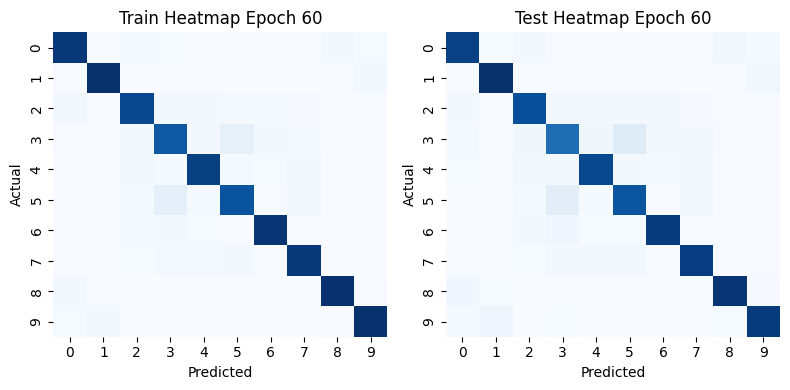

<Figure size 1200x600 with 0 Axes>

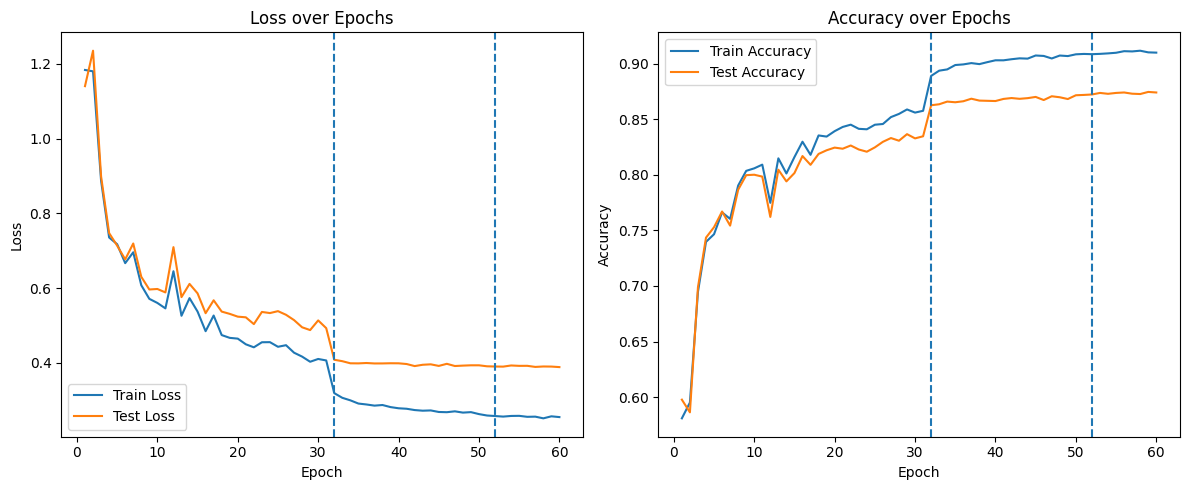

In [6]:
trainf32(model26_0,"model_weights/model26_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model26_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model26_1)
describe(model26_1)

MACs: 7.1 MMac, Params: 44.37 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32, 

Loading checkpoint from model_weights/model26_1.pt
Starting
Epoch 1/60: Train loss = 1.5223, Train accuracy = 0.5487, Test loss = 1.4171, Test accuracy = 0.5804
Epoch 2/60: Train loss = 1.1014, Train accuracy = 0.6271, Test loss = 1.0933, Test accuracy = 0.6308
Epoch 3/60: Train loss = 0.7773, Train accuracy = 0.7250, Test loss = 0.8150, Test accuracy = 0.7181


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 4/60: Train loss = 0.8236, Train accuracy = 0.7236, Test loss = 0.8481, Test accuracy = 0.7217
Epoch 5/60: Train loss = 0.6813, Train accuracy = 0.7648, Test loss = 0.6873, Test accuracy = 0.7633
Epoch 6/60: Train loss = 0.6873, Train accuracy = 0.7588, Test loss = 0.7183, Test accuracy = 0.7548
Epoch 7/60: Train loss = 0.5826, Train accuracy = 0.7956, Test loss = 0.6300, Test accuracy = 0.7825
Epoch 8/60: Train loss = 0.5728, Train accuracy = 0.8014, Test loss = 0.5922, Test accuracy = 0.7973
Epoch 9/60: Train loss = 0.6047, Train accuracy = 0.7868, Test loss = 0.6407, Test accuracy = 0.7832
Epoch 10/60: Train loss = 0.5909, Train accuracy = 0.7941, Test loss = 0.6405, Test accuracy = 0.7850
Epoch 11/60: Train loss = 0.5589, Train accuracy = 0.8065, Test loss = 0.6054, Test accuracy = 0.7989
Epoch 12/60: Train loss = 0.5168, Train accuracy = 0.8217, Test loss = 0.5616, Test accuracy = 0.8043
Epoch 13/60: Train loss = 0.5132, Train accuracy = 0.8210, Test loss = 0.5633, Test accu

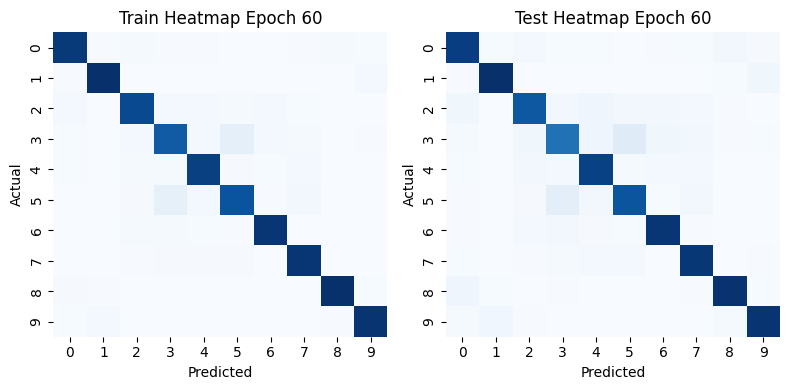

<Figure size 1200x600 with 0 Axes>

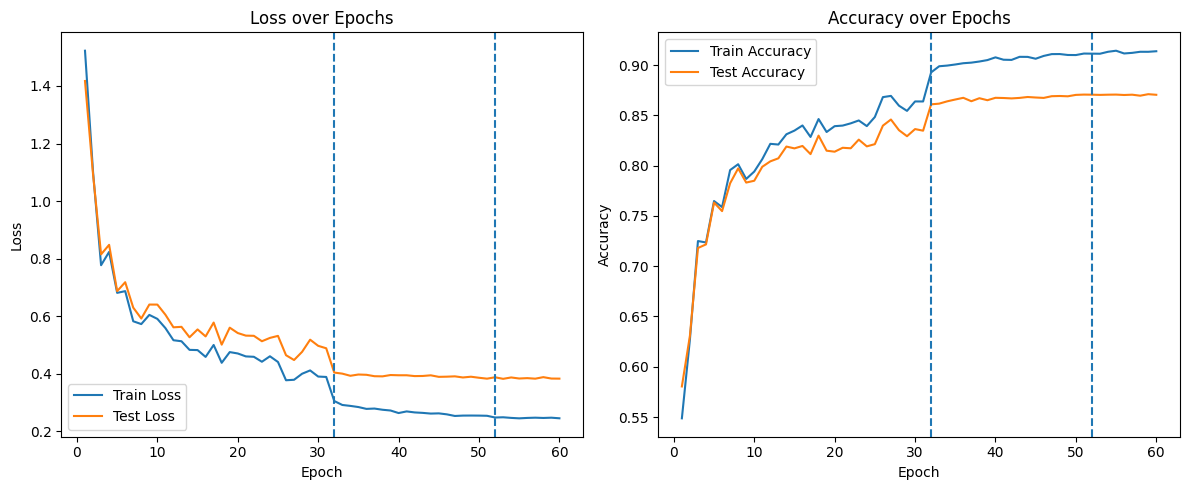

In [8]:
trainf32(model26_1,"model_weights/model26_1.pt",criterion,train_dataset,val_dataset, batch_size=64)